In [92]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [93]:
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='/cnn_data',train=True,download=True,transform=transform)
test_data = datasets.MNIST(root='/cnn_data',train=False,download=True,transform=transform)

In [94]:
test_data


Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [95]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [96]:
train_loader = DataLoader(train_data,batch_size=10,shuffle=True)
test_loader = DataLoader(test_data,batch_size=10,shuffle=False)

In [97]:
conv1 =nn.Conv2d(1,6,3,1)
conv2 =nn.Conv2d(6,16,3,1)

In [98]:
for i,(X_Train,y_train) in enumerate(train_data):
  break

In [99]:
X_Train.shape

torch.Size([1, 28, 28])

In [100]:
x = X_Train.view(1,1,28,28)

In [101]:
x = F.relu(conv1(x))

In [102]:
x.shape

torch.Size([1, 6, 26, 26])

In [103]:
x = F.max_pool2d(x,2,2)

In [104]:
x.shape

torch.Size([1, 6, 13, 13])

In [105]:
x = F.relu(conv2(x))

In [106]:
x.shape

torch.Size([1, 16, 11, 11])

In [107]:
x = F.max_pool2d(x,2,2)

In [108]:
x.shape

torch.Size([1, 16, 5, 5])

In [109]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,1)
        self.conv2 = nn.Conv2d(6,16,3,1)
        self.fc1 = nn.Linear(5*5*16,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,18)
    
    def forward(self,x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x,2,2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x,2,2)

        x = x.view(-1,16*5*5)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        X = self.fc3(x)
        return F.log_softmax(X,dim=1)

In [110]:
torch.manual_seed(41)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=18, bias=True)
)

In [111]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [112]:
import time
start_time = time.time()

epochs = 5
train_losses =[]
test_losses = []
train_correct = []
test_correct = []


for i in range(epochs):
    trn_corr = 0
    tst_corr = 0


    for b,(X_train,y_train) in enumerate(train_loader):
        b+=1
        y_pred = model(X_train)
        loss = criterion(y_pred,y_train)

        predicted = torch.max(y_pred.data,1)[1]
        batch_corr =(predicted == y_train).sum()
        trn_corr += batch_corr.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b% 600 == 0:
            print(f'Epoch:{i} Batch:{b} Loss:{loss.item()}')
    train_losses.append(loss)
    train_correct.append(trn_corr)

    with torch.no_grad():
        for b,(x_test,y_test) in enumerate(test_loader):
            y_val = model(x_test)
            predicted = torch.max(y_val.data,1)[1]
            tst_corr += (predicted == y_test).sum().item()
    loss = criterion(y_val,y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)


current_time = time.time()
total = current_time - start_time
print(f'Training Took:{total/60} minutes')

Epoch:0 Batch:600 Loss:0.7962599992752075
Epoch:0 Batch:1200 Loss:0.5756745338439941
Epoch:0 Batch:1800 Loss:0.03234528750181198
Epoch:0 Batch:2400 Loss:0.1078801155090332
Epoch:0 Batch:3000 Loss:0.02664562128484249
Epoch:0 Batch:3600 Loss:0.29560521245002747
Epoch:0 Batch:4200 Loss:0.38213855028152466
Epoch:0 Batch:4800 Loss:0.17914488911628723
Epoch:0 Batch:5400 Loss:0.22075255215168
Epoch:0 Batch:6000 Loss:0.02598709799349308
Epoch:1 Batch:600 Loss:0.0011622008169069886
Epoch:1 Batch:1200 Loss:0.0013344843173399568
Epoch:1 Batch:1800 Loss:0.16393104195594788
Epoch:1 Batch:2400 Loss:0.010886894538998604
Epoch:1 Batch:3000 Loss:0.001047885394655168
Epoch:1 Batch:3600 Loss:0.05847637727856636
Epoch:1 Batch:4200 Loss:0.0005863101687282324
Epoch:1 Batch:4800 Loss:0.00014023935364093632
Epoch:1 Batch:5400 Loss:0.12907496094703674
Epoch:1 Batch:6000 Loss:0.7577276229858398
Epoch:2 Batch:600 Loss:0.001325368182733655
Epoch:2 Batch:1200 Loss:0.0034185710828751326
Epoch:2 Batch:1800 Loss:0.06

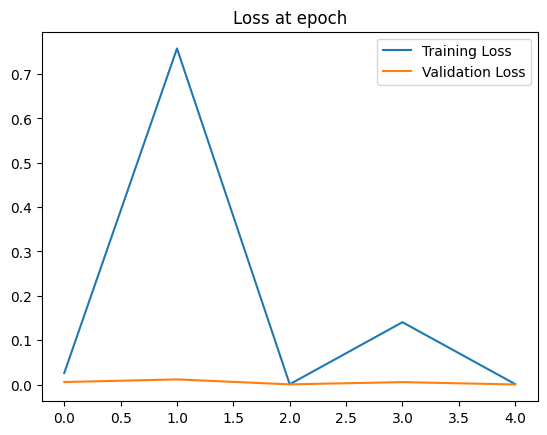

In [113]:
plt.plot([x.item() for x in train_losses],label='Training Loss')
plt.plot([x.item() for x in test_losses],label='Validation Loss')
plt.title("Loss at epoch")
plt.legend()

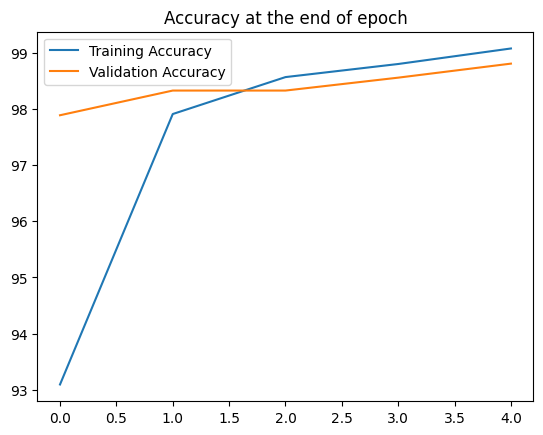

In [114]:
plt.plot([t/60000 * 100 for t in train_correct],label='Training Accuracy')
plt.plot([t/10000 * 100 for t in test_correct],label='Validation Accuracy')
plt.title('Accuracy at the end of epoch')
plt.legend()

In [115]:
test_load_everything = DataLoader(test_data,batch_size=10000,shuffle=False)

In [116]:
with torch.no_grad():
    correct = 0
    for X_test,y_test in test_loader:
        y_val = model(X_test)
        predicted = torch.max(y_val,1)[1]
        correct += (predicted == y_test).sum()

In [117]:
correct.item()/len(test_data)*100

98.81

In [118]:
test_data[4142] 


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [119]:
test_data[4142][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

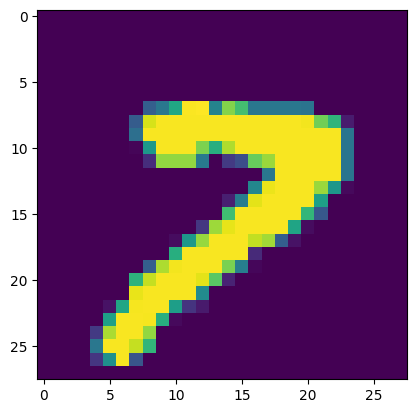

In [120]:
plt.imshow(test_data[4142][0].reshape(28,28))

In [121]:
model.eval()
with torch.no_grad():
    new_prediction = model(test_data[4142][0].view(1,1,28,28))

In [122]:
new_prediction

tensor([[-1.4561e+01, -1.1268e+01, -8.4649e+00, -1.1381e+01, -1.2487e+01,
         -1.4785e+01, -2.5247e+01, -2.9583e-04, -1.3142e+01, -9.8225e+00,
         -3.6260e+01, -3.6686e+01, -3.6001e+01, -3.5497e+01, -3.5541e+01,
         -3.6031e+01, -3.6022e+01, -3.5469e+01]])

In [123]:
new_prediction.argmax()

tensor(7)

In [124]:
print(f"Predicted: {new_prediction.argmax().item()}")
print(f"Actual Label: {test_data[4142][1]}")

Predicted: 7
Actual Label: 7
